In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
train_df = pd.read_csv("/kaggle/input/datasets/shreyash28/pharma-dataset/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/shreyash28/pharma-dataset/test.csv")
sub_df = pd.read_csv("/kaggle/input/datasets/shreyash28/pharma-dataset/sample_submission.csv")

In [6]:
import pandas as pd

train_df = pd.read_csv("/kaggle/input/datasets/shreyash28/pharma-dataset/train.csv")

print("Shape:", train_df.shape)

print("\nColumns & Dtypes:")
print(train_df.dtypes)

print("\nHead:")
display(train_df.head())

print("\nDescribe (numeric):")
display(train_df.describe())

print("\nNull counts:")
print(train_df.isnull().sum())

cat_cols = train_df.select_dtypes(include='object').columns
if len(cat_cols) > 0:
    print("\nCategorical column unique value counts:")
    for col in cat_cols:
        print(f"  {col}: {train_df[col].nunique()} unique → {train_df[col].unique()[:5]}")

Shape: (22083, 45)

Columns & Dtypes:
Patient Id                                           object
Patient Age                                         float64
Genes in mother's side                               object
Inherited from father                                object
Maternal gene                                        object
Paternal gene                                        object
Blood cell count (mcL)                              float64
Patient First Name                                   object
Family Name                                          object
Father's name                                        object
Mother's age                                        float64
Father's age                                        float64
Institute Name                                       object
Location of Institute                                object
Status                                               object
Respiratory Rate (breaths/min)                       object
He

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,Yes,No,4.760603,Richard,NaN,Larre,...,NaN,9.857562,NaN,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,PID0x25d5,4.0,Yes,Yes,No,No,4.910669,Mike,NaN,Brycen,...,Multiple,5.522560,normal,1.0,NaN,1.0,1.0,0.0,NaN,Cystic fibrosis
2,PID0x4a82,6.0,Yes,No,No,No,4.893297,Kimberly,NaN,Nashon,...,Singular,NaN,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
3,PID0x4ac8,12.0,Yes,No,Yes,No,4.705280,Jeffery,Hoelscher,Aayaan,...,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,PID0x1bf7,11.0,Yes,No,NaN,Yes,4.720703,Johanna,Stutzman,Suave,...,Multiple,4.098210,NaN,0.0,0.0,0.0,0.0,NaN,Multifactorial genetic inheritance disorders,Cancer



Describe (numeric):


,Patient Age,Blood cell count (mcL),Mother's age,Father's age,Test 1,Test 2,Test 3,Test 4,Test 5,No. of previous abortion,White Blood cell count (thousand per microliter),Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
count,20656.000000,22083.000000,16047.000000,16097.000000,19956.0,19931.0,19936.0,19943.0,19913.0,19921.000000,19935.000000,19928.000000,19861.000000,19982.000000,19970.000000,19930.000000
mean,6.974148,4.898871,34.526454,41.972852,0.0,0.0,0.0,1.0,0.0,2.003062,7.486224,0.592483,0.551886,0.536233,0.497747,0.461917
std,4.319475,0.199663,9.852598,13.035501,0.0,0.0,0.0,0.0,0.0,1.411919,2.653393,0.491385,0.497313,0.498698,0.500007,0.498560
min,0.000000,4.092727,18.000000,20.000000,0.0,0.0,0.0,1.0,0.0,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.763109,26.000000,31.000000,0.0,0.0,0.0,1.0,0.0,1.000000,5.424703,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,4.899399,35.000000,42.000000,0.0,0.0,0.0,1.0,0.0,2.000000,7.477132,1.000000,1.000000,1.000000,0.000000,0.000000
75%,11.000000,5.033830,43.000000,53.000000,0.0,0.0,0.0,1.0,0.0,3.000000,9.526152,1.000000,1.000000,1.000000,1.000000,1.000000
max,14.000000,5.609829,51.000000,64.000000,0.0,0.0,0.0,1.0,0.0,4.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Null counts:
Patient Id                                             0
Patient Age                                         1427
Genes in mother's side                                 0
Inherited from father                                306
Maternal gene                                       2810
Paternal gene                                          0
Blood cell count (mcL)                                 0
Patient First Name                                     0
Family Name                                         9691
Father's name                                          0
Mother's age                                        6036
Father's age                                        5986
Institute Name                                      5106
Location of Institute                                  0
Status                                                 0
Respiratory Rate (breaths/min)                      2149
Heart Rate (rates/min                               2113
Test 1           


# **Problem TypeDual multi-class classification — you need to predict two targets simultaneously:TargetClassesGenetic Disorder3 classes (Mitochondrial, Multifactorial, Single-gene)Disorder Subclass9 classes (Cystic fibrosis, Diabetes, Cancer, Leigh syndrome, Leber's, etc.)** 

#  Feature Landscape (45 cols)
Numeric (keep & impute):

1. Patient Age, Mother's age, Father's age
2. Blood cell count (mcl), White Blood cell count
3. Test 1–5 (likely lab values)
4. Symptom 1–5 (looks like 0/1 flags but stored as float)
5. No. of previous abortion

# Low-cardinality categoricals (encode):
1. Genes in mother's side, Inherited from father, Maternal gene, Paternal gene → Yes/No
2. Gender → Male/Female/Ambiguous
3. Status → Alive/Decease
4. Respiratory Rate → Normal/Tachypnea
5. Heart Rate → Normal/Tachycardia
6. Blood test result → normal / inconclusive / slightly abnormal / abnormal
7. Birth defects → Singular/Multiple
8. Birth asphyxia, H/O serious maternal illness, H/O radiation exposure (x-ray), H/O substance abuse, Assisted conception IVF/ART, History of anomalies in previous pregnancies → Yes/No/Not applicable
9. Folic acid details (peri-conceptional) → Yes/No
10. Place of birth → Institute/Home

# Noise / drop candidates:
1. Patient Id, Patient First Name, Family Name, Father's name — pure identifiers, zero signal
2. Institute Name, Location of Institute — 27 and 26 unique values, mostly addresses, very noisy

# Near-zero variance (check):
1. Test 1–5 — describe shows mean ≈ 0, std ≈ 0 — likely sparse binary flags, verify
2. Parental consent — 1 unique value → drop immediately

# 🕳️ Missing Data Situation
Every column has ~2100–2200 nulls out of 22,083 rows (~10% per column). This is systematic but manageable. Strategy:

Numeric → median imputation (or iterative imputer)
Categorical → mode imputation or a dedicated "Unknown" category

#  Key Challenges (matching the PS)
1. Class imbalance — 9 subclasses, likely uneven distribution
2. Heterogeneous types — mixed numeric + categorical
3. Hierarchical targets — Genetic Disorder → Disorder Subclass; you can exploit this with a chained/hierarchical classifier
4. Noisy categoricals — inconsistent values like '-', 'No record', 'Not available'

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.multioutput import MultiOutputClassifier

import lightgbm as lgb
import xgboost as xgb

plt.rcParams['figure.dpi'] = 110

train_df = pd.read_csv("/kaggle/input/datasets/shreyash28/pharma-dataset/train.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/shreyash28/pharma-dataset/test.csv")
sub_df   = pd.read_csv("/kaggle/input/datasets/shreyash28/pharma-dataset/sample_submission.csv")

TARGET1 = 'Genetic Disorder'
TARGET2 = 'Disorder Subclass'

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (22083, 45)
Test : (9465, 43)


In [8]:
print("Shape:", train_df.shape)
print("\nDtypes:\n", train_df.dtypes)
display(train_df.head())
display(train_df.describe())

Shape: (22083, 45)

Dtypes:
 Patient Id                                           object
Patient Age                                         float64
Genes in mother's side                               object
Inherited from father                                object
Maternal gene                                        object
Paternal gene                                        object
Blood cell count (mcL)                              float64
Patient First Name                                   object
Family Name                                          object
Father's name                                        object
Mother's age                                        float64
Father's age                                        float64
Institute Name                                       object
Location of Institute                                object
Status                                               object
Respiratory Rate (breaths/min)                       object
Heart Rate 

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,Yes,No,4.760603,Richard,NaN,Larre,...,NaN,9.857562,NaN,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,PID0x25d5,4.0,Yes,Yes,No,No,4.910669,Mike,NaN,Brycen,...,Multiple,5.522560,normal,1.0,NaN,1.0,1.0,0.0,NaN,Cystic fibrosis
2,PID0x4a82,6.0,Yes,No,No,No,4.893297,Kimberly,NaN,Nashon,...,Singular,NaN,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
3,PID0x4ac8,12.0,Yes,No,Yes,No,4.705280,Jeffery,Hoelscher,Aayaan,...,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,PID0x1bf7,11.0,Yes,No,NaN,Yes,4.720703,Johanna,Stutzman,Suave,...,Multiple,4.098210,NaN,0.0,0.0,0.0,0.0,NaN,Multifactorial genetic inheritance disorders,Cancer


,Patient Age,Blood cell count (mcL),Mother's age,Father's age,Test 1,Test 2,Test 3,Test 4,Test 5,No. of previous abortion,White Blood cell count (thousand per microliter),Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
count,20656.000000,22083.000000,16047.000000,16097.000000,19956.0,19931.0,19936.0,19943.0,19913.0,19921.000000,19935.000000,19928.000000,19861.000000,19982.000000,19970.000000,19930.000000
mean,6.974148,4.898871,34.526454,41.972852,0.0,0.0,0.0,1.0,0.0,2.003062,7.486224,0.592483,0.551886,0.536233,0.497747,0.461917
std,4.319475,0.199663,9.852598,13.035501,0.0,0.0,0.0,0.0,0.0,1.411919,2.653393,0.491385,0.497313,0.498698,0.500007,0.498560
min,0.000000,4.092727,18.000000,20.000000,0.0,0.0,0.0,1.0,0.0,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.763109,26.000000,31.000000,0.0,0.0,0.0,1.0,0.0,1.000000,5.424703,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,4.899399,35.000000,42.000000,0.0,0.0,0.0,1.0,0.0,2.000000,7.477132,1.000000,1.000000,1.000000,0.000000,0.000000
75%,11.000000,5.033830,43.000000,53.000000,0.0,0.0,0.0,1.0,0.0,3.000000,9.526152,1.000000,1.000000,1.000000,1.000000,1.000000
max,14.000000,5.609829,51.000000,64.000000,0.0,0.0,0.0,1.0,0.0,4.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000


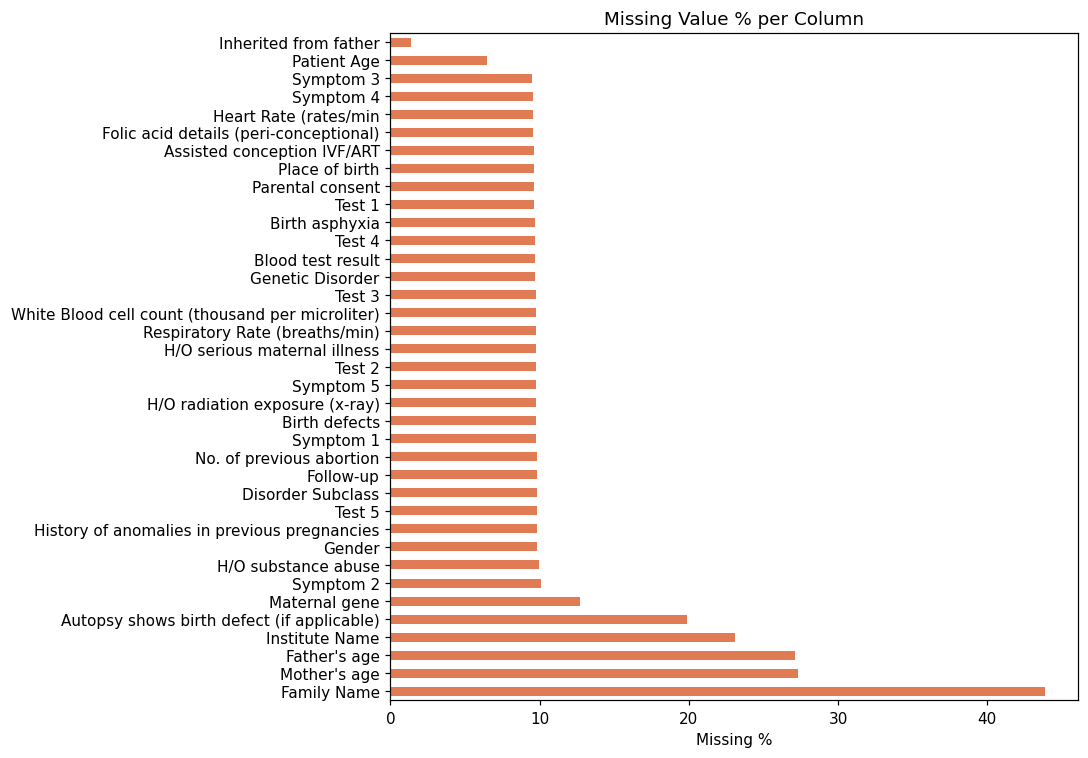

Family Name                                         43.884436
Mother's age                                        27.333243
Father's age                                        27.106824
Institute Name                                      23.121858
Autopsy shows birth defect (if applicable)          19.888602
Maternal gene                                       12.724720
Symptom 2                                           10.062039
H/O substance abuse                                  9.939773
Gender                                               9.840149
History of anomalies in previous pregnancies         9.835620
Test 5                                               9.826563
Disorder Subclass                                    9.817507
Follow-up                                            9.808450
No. of previous abortion                             9.790336
Symptom 1                                            9.758638
Birth defects                                        9.754109
H/O radi

In [9]:
miss = (train_df.isnull().sum() / len(train_df) * 100).sort_values(ascending=False)
miss = miss[miss > 0]

plt.figure(figsize=(10, 7))
miss.plot(kind='barh', color='#e07b54')
plt.xlabel('Missing %')
plt.title('Missing Value % per Column')
plt.tight_layout()
plt.show()

print(miss)

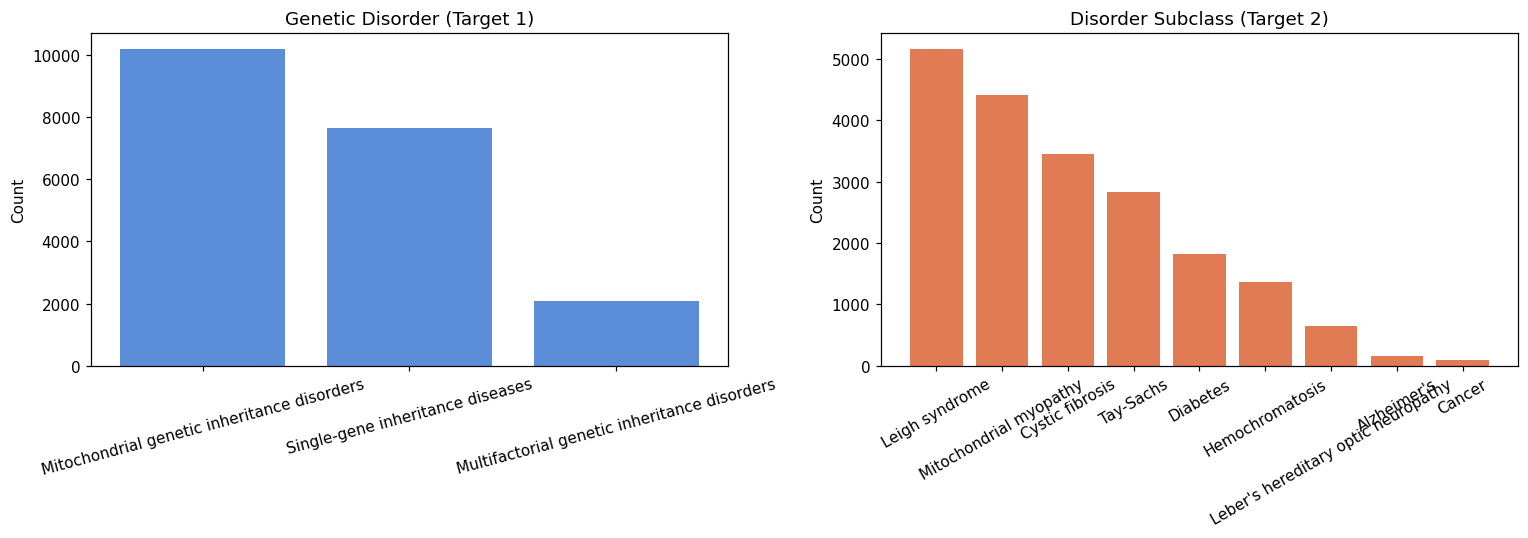


Genetic Disorder:
 Genetic Disorder
Mitochondrial genetic inheritance disorders     10202
Single-gene inheritance diseases                 7664
Multifactorial genetic inheritance disorders     2071
Name: count, dtype: int64

Disorder Subclass:
 Disorder Subclass
Leigh syndrome                         5160
Mitochondrial myopathy                 4405
Cystic fibrosis                        3448
Tay-Sachs                              2833
Diabetes                               1817
Hemochromatosis                        1355
Leber's hereditary optic neuropathy     648
Alzheimer's                             152
Cancer                                   97
Name: count, dtype: int64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vc1 = train_df[TARGET1].value_counts()
vc2 = train_df[TARGET2].value_counts()

axes[0].bar(vc1.index, vc1.values, color='#5b8dd9')
axes[0].set_title('Genetic Disorder (Target 1)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(vc2.index, vc2.values, color='#e07b54')
axes[1].set_title('Disorder Subclass (Target 2)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\nGenetic Disorder:\n", vc1)
print("\nDisorder Subclass:\n", vc2)

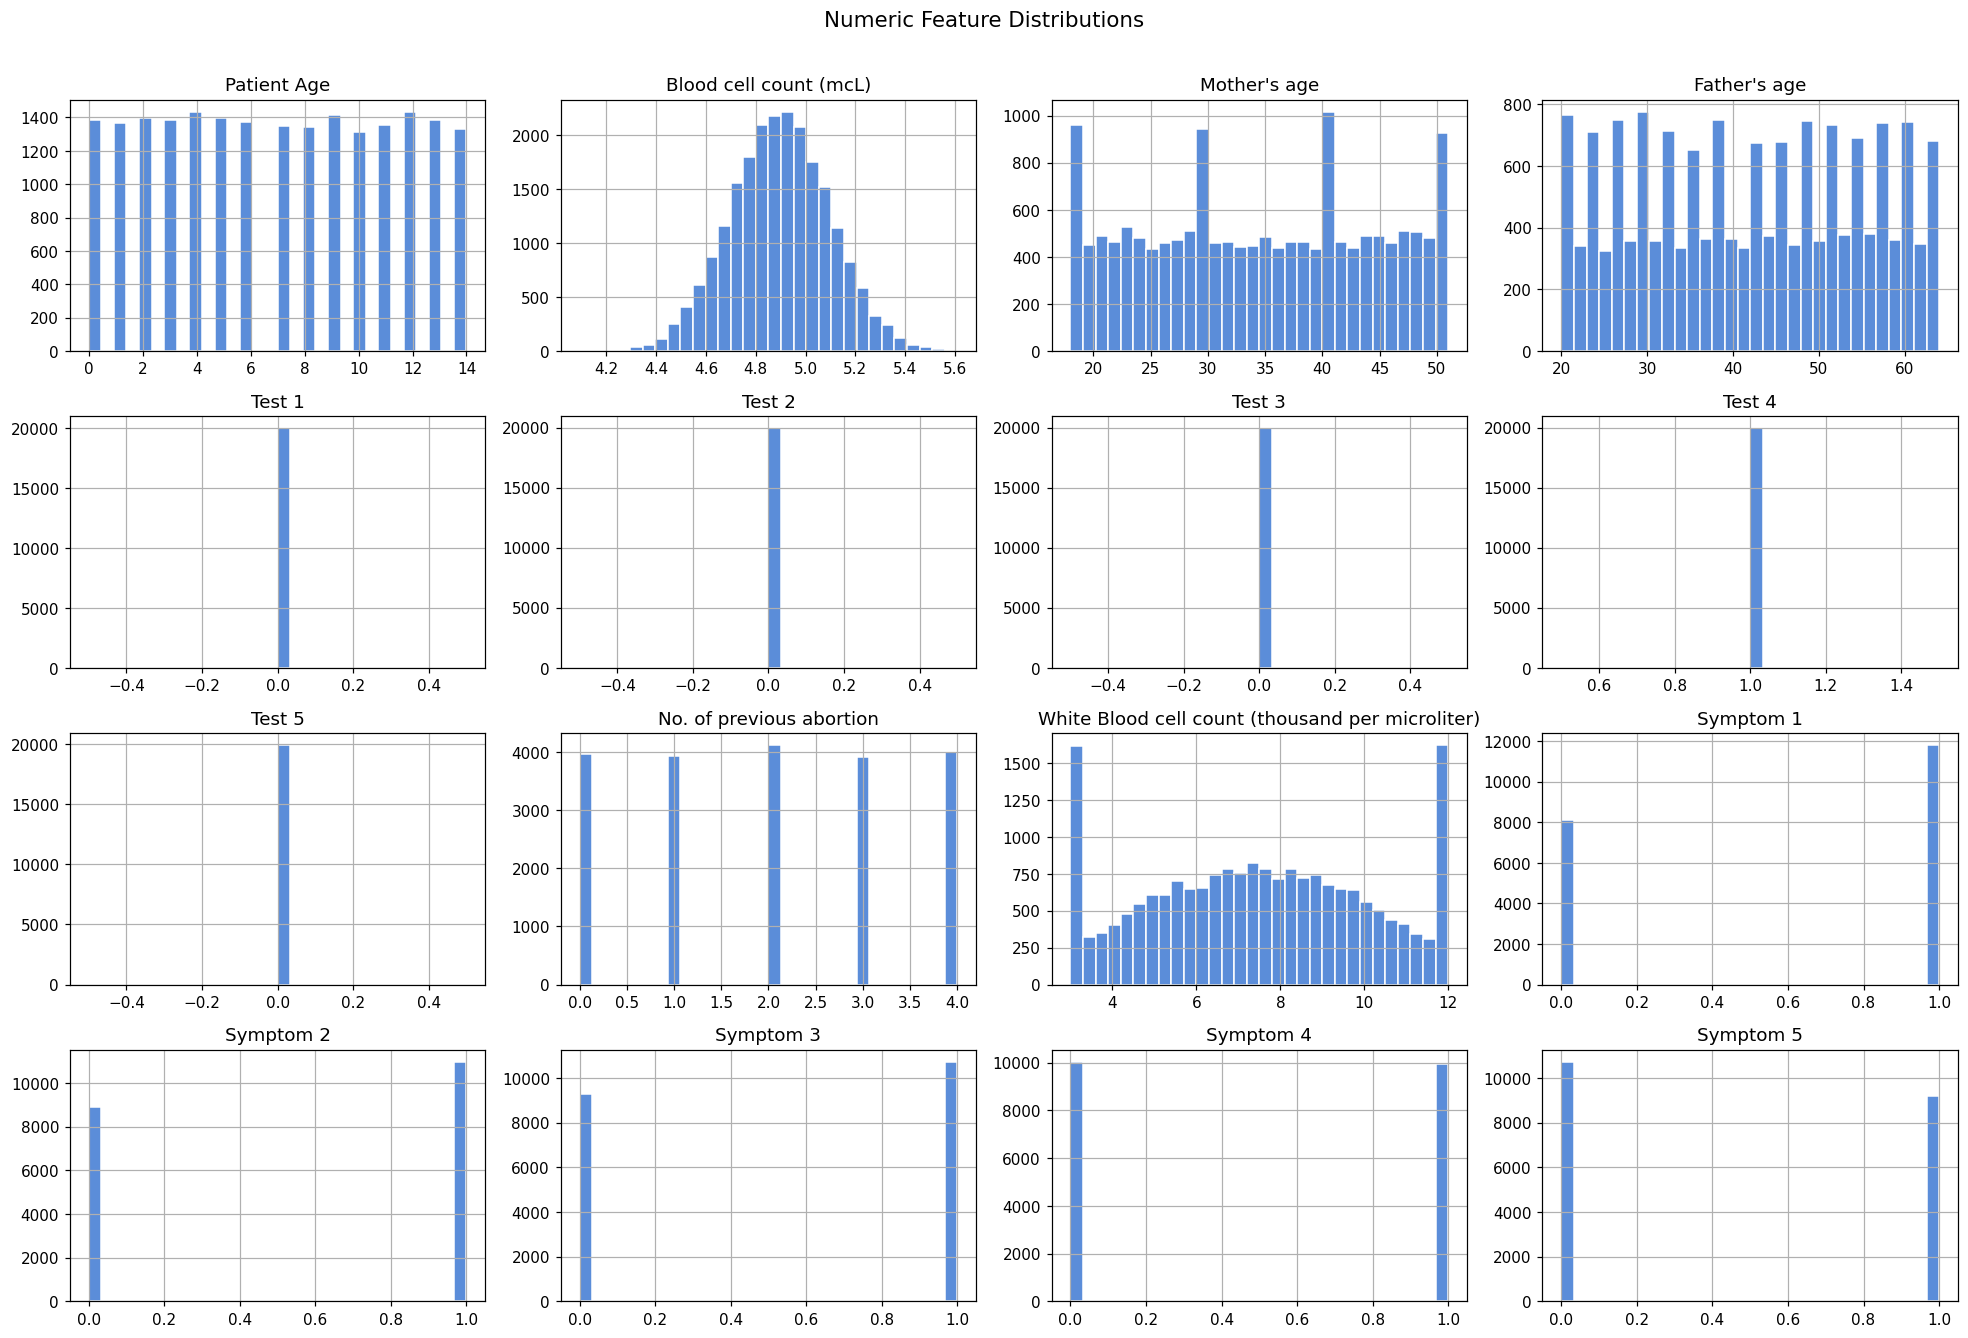

In [11]:
num_cols = train_df.select_dtypes(include='number').columns.tolist()
# remove targets if they sneak in as numeric
num_cols = [c for c in num_cols if c not in [TARGET1, TARGET2]]

train_df[num_cols].hist(bins=30, figsize=(18, 12), color='#5b8dd9', edgecolor='white')
plt.suptitle('Numeric Feature Distributions', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

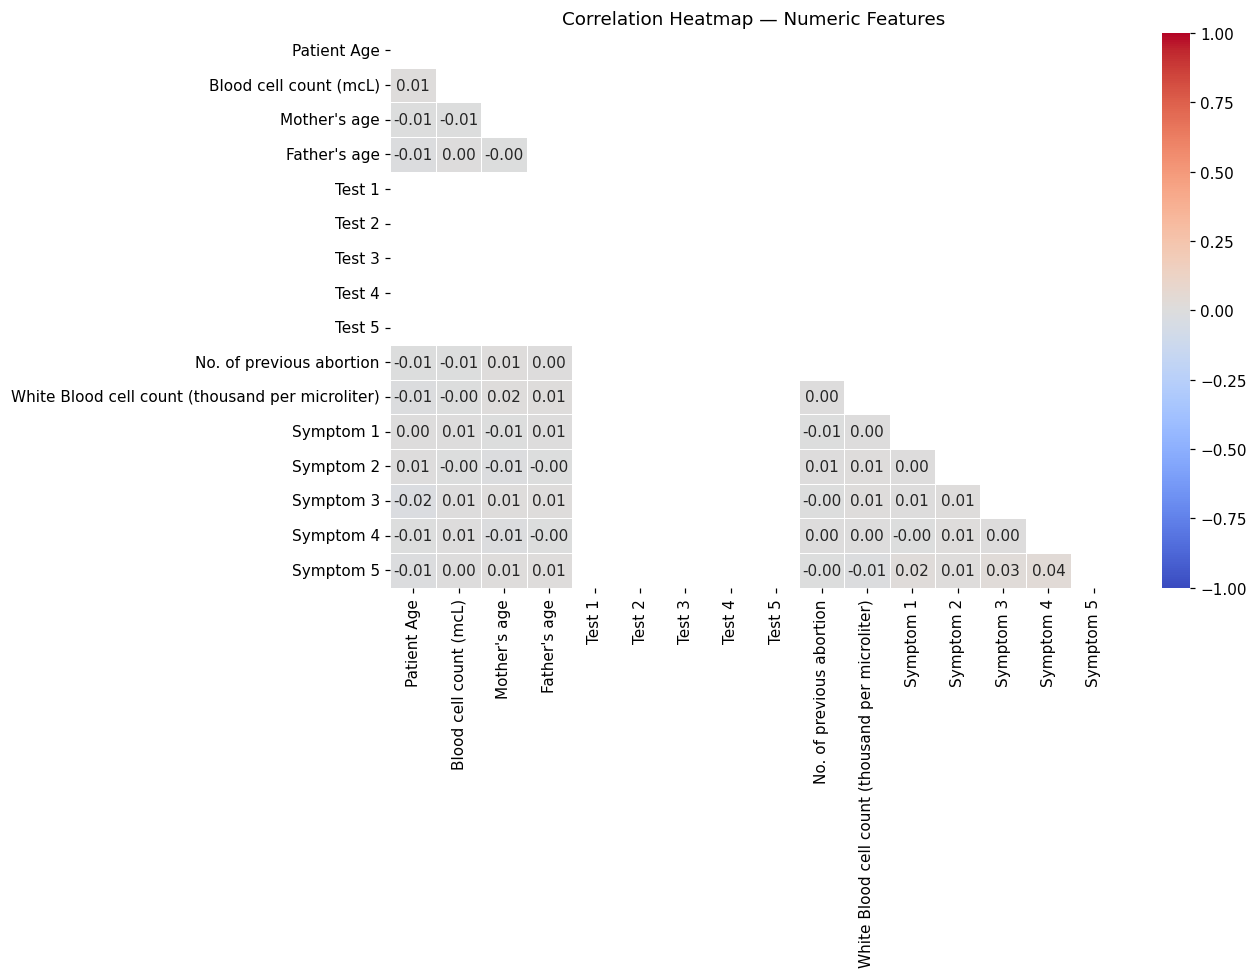

In [12]:
corr = train_df[num_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

In [13]:
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in [TARGET1, TARGET2]]

for col in cat_cols:
    n = train_df[col].nunique()
    samples = train_df[col].dropna().unique()[:6]
    print(f"  {col:<50} {n:>4} unique  →  {samples}")

  Patient Id                                         22083 unique  →  ['PID0x6418' 'PID0x25d5' 'PID0x4a82' 'PID0x4ac8' 'PID0x1bf7' 'PID0x44fe']
  Genes in mother's side                                2 unique  →  ['Yes' 'No']
  Inherited from father                                 2 unique  →  ['No' 'Yes']
  Maternal gene                                         2 unique  →  ['Yes' 'No']
  Paternal gene                                         2 unique  →  ['No' 'Yes']
  Patient First Name                                 2524 unique  →  ['Richard' 'Mike' 'Kimberly' 'Jeffery' 'Johanna' 'Mary']
  Family Name                                        6282 unique  →  ['Hoelscher' 'Stutzman' 'Bryant' 'Camacho' 'Sandoval' 'Harness']
  Father's name                                      16368 unique  →  ['Larre' 'Brycen' 'Nashon' 'Aayaan' 'Suave' 'Coleston']
  Institute Name                                       27 unique  →  ['Boston Specialty & Rehabilitation Hospital'
 "St. Margaret's Hospital F

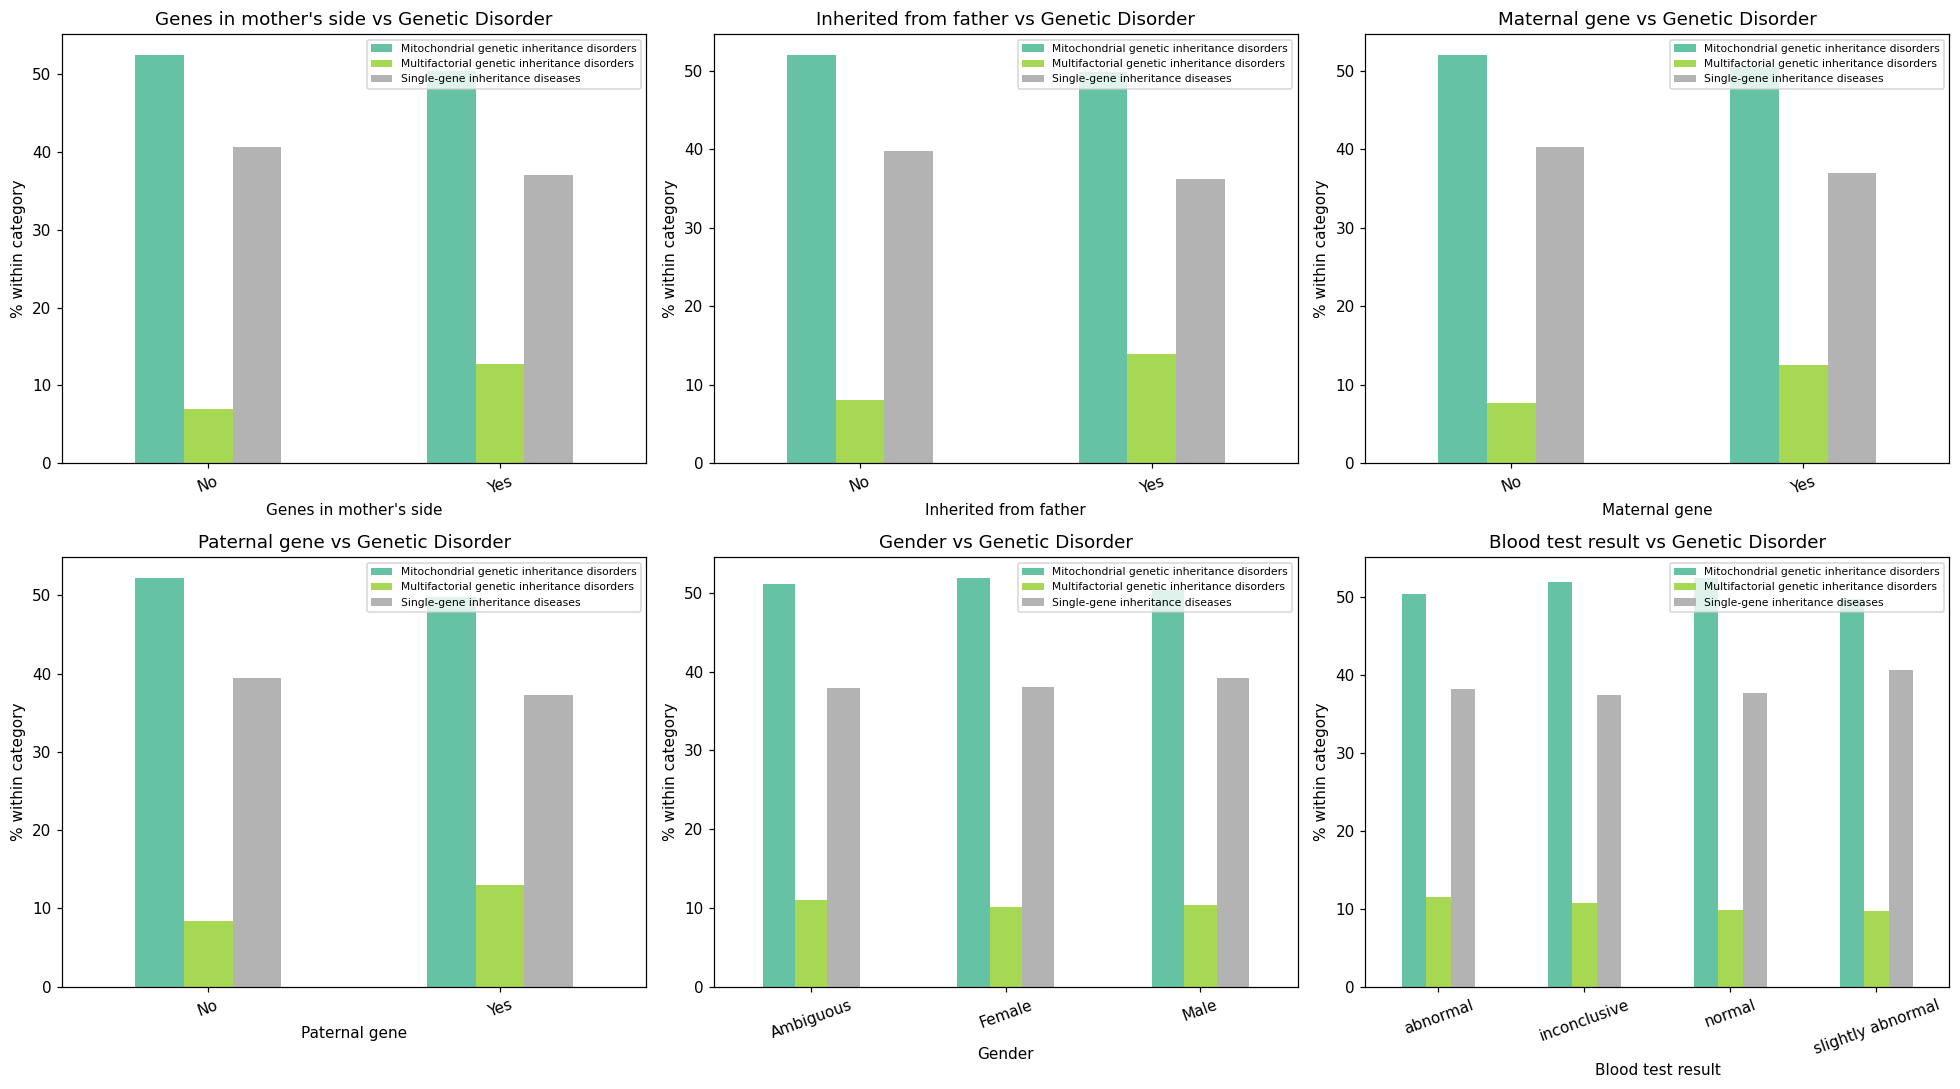

In [14]:
key_cats = [
    'Genes in mother\'s side', 'Inherited from father',
    'Maternal gene', 'Paternal gene', 'Gender', 'Blood test result'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    ct = pd.crosstab(train_df[col], train_df[TARGET1], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='none')
    axes[i].set_title(f'{col} vs Genetic Disorder')
    axes[i].set_ylabel('% within category')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].legend(loc='upper right', fontsize=7)

plt.tight_layout()
plt.show()

Symptom 1: {1.0: 11807, 0.0: 8121}
Symptom 2: {1.0: 10961, 0.0: 8900}
Symptom 3: {1.0: 10715, 0.0: 9267}
Symptom 4: {0.0: 10030, 1.0: 9940}
Symptom 5: {0.0: 10724, 1.0: 9206}


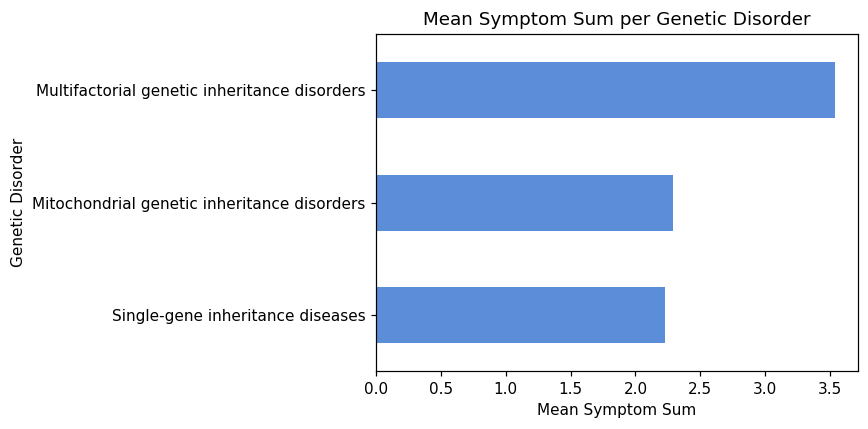

In [15]:
symptom_cols = ['Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5']

for col in symptom_cols:
    print(f"{col}: {train_df[col].value_counts().to_dict()}")

train_df['symptom_sum'] = train_df[symptom_cols].sum(axis=1)

plt.figure(figsize=(8, 4))
train_df.groupby(TARGET1)['symptom_sum'].mean().sort_values().plot(kind='barh', color='#5b8dd9')
plt.title('Mean Symptom Sum per Genetic Disorder')
plt.xlabel('Mean Symptom Sum')
plt.tight_layout()
plt.show()

train_df.drop(columns=['symptom_sum'], inplace=True)

In [16]:
DROP_COLS = [
    'Patient Id', 'Patient First Name', 'Family Name', "Father's name",
    'Location of Institute', 'Parental consent', 'Institute Name'
]

train_df.drop(columns=DROP_COLS, inplace=True, errors='ignore')
test_df.drop(columns=DROP_COLS,  inplace=True, errors='ignore')

print("After drop — Train:", train_df.shape, "| Test:", test_df.shape)

After drop — Train: (22083, 38) | Test: (9465, 36)


In [17]:
NOISY = ['-', 'No record', 'Not available', 'None', 'none', 'nan', ' ']

def clean_noisy(df):
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].replace(NOISY, np.nan)
        df[col] = df[col].str.strip()
        df[col] = df[col].replace('', np.nan)
    return df

train_df = clean_noisy(train_df)
test_df  = clean_noisy(test_df)

print("Noisy values cleaned.")
print("Remaining nulls per column:\n", train_df.isnull().sum()[train_df.isnull().sum() > 0])

Noisy values cleaned.
Remaining nulls per column:
 Patient Age                                          1427
Inherited from father                                 306
Maternal gene                                        2810
Mother's age                                         6036
Father's age                                         5986
Respiratory Rate (breaths/min)                       2149
Heart Rate (rates/min                                2113
Test 1                                               2127
Test 2                                               2152
Test 3                                               2147
Test 4                                               2140
Test 5                                               2170
Follow-up                                            2166
Gender                                               2173
Birth asphyxia                                      12133
Autopsy shows birth defect (if applicable)           4392
Place of birth       

In [18]:
y1 = train_df[TARGET1].copy()
y2 = train_df[TARGET2].copy()

X_train_raw = train_df.drop(columns=[TARGET1, TARGET2])
X_test_raw  = test_df.copy()

print("X_train_raw:", X_train_raw.shape)
print("y1 classes:", y1.unique())
print("y2 classes:", y2.unique())

X_train_raw: (22083, 36)
y1 classes: ['Mitochondrial genetic inheritance disorders' nan
 'Multifactorial genetic inheritance disorders'
 'Single-gene inheritance diseases']
y2 classes: ["Leber's hereditary optic neuropathy" 'Cystic fibrosis' 'Diabetes'
 'Leigh syndrome' 'Cancer' 'Tay-Sachs' 'Hemochromatosis'
 'Mitochondrial myopathy' nan "Alzheimer's"]


In [19]:
num_cols = X_train_raw.select_dtypes(include='number').columns.tolist()
cat_cols = X_train_raw.select_dtypes(include='object').columns.tolist()

binary_cols = [c for c in cat_cols
               if X_train_raw[c].dropna().nunique() <= 3]

multi_cols = [c for c in cat_cols
              if X_train_raw[c].dropna().nunique() > 3]

print("Numeric cols  :", len(num_cols),  "→", num_cols)
print("Binary cats   :", len(binary_cols), "→", binary_cols)
print("Multi  cats   :", len(multi_cols),  "→", multi_cols)

Numeric cols  : 16 → ['Patient Age', 'Blood cell count (mcL)', "Mother's age", "Father's age", 'Test 1', 'Test 2', 'Test 3', 'Test 4', 'Test 5', 'No. of previous abortion', 'White Blood cell count (thousand per microliter)', 'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5']
Binary cats   : 19 → ["Genes in mother's side", 'Inherited from father', 'Maternal gene', 'Paternal gene', 'Status', 'Respiratory Rate (breaths/min)', 'Heart Rate (rates/min', 'Follow-up', 'Gender', 'Birth asphyxia', 'Autopsy shows birth defect (if applicable)', 'Place of birth', 'Folic acid details (peri-conceptional)', 'H/O serious maternal illness', 'H/O radiation exposure (x-ray)', 'H/O substance abuse', 'Assisted conception IVF/ART', 'History of anomalies in previous pregnancies', 'Birth defects']
Multi  cats   : 1 → ['Blood test result']


In [20]:
def preprocess(X_tr, X_te, num_cols, binary_cols, multi_cols):
    X_tr = X_tr.copy()
    X_te = X_te.copy()

    num_imp = SimpleImputer(strategy='median')
    X_tr[num_cols] = num_imp.fit_transform(X_tr[num_cols])
    X_te[num_cols] = num_imp.transform(X_te[num_cols])

    for col in binary_cols:
        X_tr[col] = X_tr[col].fillna('Unknown')
        X_te[col] = X_te[col].fillna('Unknown')

    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_tr[binary_cols] = ord_enc.fit_transform(X_tr[binary_cols])
    X_te[binary_cols] = ord_enc.transform(X_te[binary_cols])

    for col in multi_cols:
        X_tr[col] = X_tr[col].fillna('Unknown')
        X_te[col] = X_te[col].fillna('Unknown')

    X_tr = pd.get_dummies(X_tr, columns=multi_cols, drop_first=False)
    X_te = pd.get_dummies(X_te, columns=multi_cols, drop_first=False)

    X_tr, X_te = X_tr.align(X_te, join='left', axis=1, fill_value=0)

    return X_tr, X_te


X, X_test = preprocess(X_train_raw, X_test_raw,
                        num_cols, binary_cols, multi_cols)

print("X shape     :", X.shape)
print("X_test shape:", X_test.shape)

X shape     : (22083, 40)
X_test shape: (9465, 40)


In [21]:
le1 = LabelEncoder()
le2 = LabelEncoder()

valid_mask = y1.notna() & y2.notna()
X  = X[valid_mask].reset_index(drop=True)
y1 = y1[valid_mask].reset_index(drop=True)
y2 = y2[valid_mask].reset_index(drop=True)

y1_enc = le1.fit_transform(y1)
y2_enc = le2.fit_transform(y2)

print("Target 1 classes:", dict(enumerate(le1.classes_)))
print("Target 2 classes:", dict(enumerate(le2.classes_)))

X_tr, X_val, y1_tr, y1_val, y2_tr, y2_val = train_test_split(
    X, y1_enc, y2_enc,
    test_size=0.2, random_state=42,
    stratify=y1_enc
)
print(f"\nTrain {X_tr.shape} | Val {X_val.shape}")

Target 1 classes: {0: 'Mitochondrial genetic inheritance disorders', 1: 'Multifactorial genetic inheritance disorders', 2: 'Single-gene inheritance diseases'}
Target 2 classes: {0: "Alzheimer's", 1: 'Cancer', 2: 'Cystic fibrosis', 3: 'Diabetes', 4: 'Hemochromatosis', 5: "Leber's hereditary optic neuropathy", 6: 'Leigh syndrome', 7: 'Mitochondrial myopathy', 8: 'Tay-Sachs'}

Train (14437, 40) | Val (3610, 40)


In [22]:
# ── Model for TARGET 1 (Genetic Disorder) ─────────────────
lgbm_params = dict(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    colsample_bytree=0.8,
    subsample=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model_A1 = lgb.LGBMClassifier(**lgbm_params)
model_A1.fit(
    X_tr, y1_tr,
    eval_set=[(X_val, y1_val)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=100)]
)

# ── Model for TARGET 2 (Disorder Subclass) ────────────────
model_A2 = lgb.LGBMClassifier(**lgbm_params)
model_A2.fit(
    X_tr, y2_tr,
    eval_set=[(X_val, y2_val)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=100)]
)

# ── Evaluate ───────────────────────────────────────────────
pred_A1 = model_A1.predict(X_val)
pred_A2 = model_A2.predict(X_val)

f1_A1 = f1_score(y1_val, pred_A1, average='macro')
f1_A2 = f1_score(y2_val, pred_A2, average='macro')

print(f"\n[Option A] Genetic Disorder   Macro F1 : {f1_A1:.4f}")
print(f"[Option A] Disorder Subclass  Macro F1 : {f1_A2:.4f}")

[100]	valid_0's multi_logloss: 0.881916
[200]	valid_0's multi_logloss: 0.865881
[300]	valid_0's multi_logloss: 0.85917
[400]	valid_0's multi_logloss: 0.856788
[100]	valid_0's multi_logloss: 1.43995

[Option A] Genetic Disorder   Macro F1 : 0.5138
[Option A] Disorder Subclass  Macro F1 : 0.2913


In [23]:
model_B1 = lgb.LGBMClassifier(**lgbm_params)
model_B1.fit(
    X_tr, y1_tr,
    eval_set=[(X_val, y1_val)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=100)]
)

X_tr_chain = X_tr.copy()
X_val_chain = X_val.copy()

from sklearn.model_selection import StratifiedKFold
oof_pred_B1 = np.zeros(len(X_tr), dtype=int)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (ti, vi) in enumerate(skf.split(X_tr, y1_tr)):
    _m = lgb.LGBMClassifier(**lgbm_params)
    _m.fit(X_tr.iloc[ti], y1_tr[ti],
           eval_set=[(X_tr.iloc[vi], y1_tr[vi])],
           callbacks=[lgb.early_stopping(30, verbose=False),
                      lgb.log_evaluation(period=-1)])
    oof_pred_B1[vi] = _m.predict(X_tr.iloc[vi])
    print(f"  Fold {fold+1} done")

X_tr_chain['pred_disorder']  = oof_pred_B1
X_val_chain['pred_disorder'] = model_B1.predict(X_val)

model_B2 = lgb.LGBMClassifier(**lgbm_params)
model_B2.fit(
    X_tr_chain, y2_tr,
    eval_set=[(X_val_chain, y2_val)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=100)]
)

pred_B1 = model_B1.predict(X_val)
pred_B2 = model_B2.predict(X_val_chain)

f1_B1 = f1_score(y1_val, pred_B1, average='macro')
f1_B2 = f1_score(y2_val, pred_B2, average='macro')

print(f"\n[Option B] Genetic Disorder   Macro F1 : {f1_B1:.4f}")
print(f"[Option B] Disorder Subclass  Macro F1 : {f1_B2:.4f}")

[100]	valid_0's multi_logloss: 0.881916
[200]	valid_0's multi_logloss: 0.865881
[300]	valid_0's multi_logloss: 0.85917
[400]	valid_0's multi_logloss: 0.856788
  Fold 1 done
  Fold 2 done
  Fold 3 done
  Fold 4 done
  Fold 5 done
[100]	valid_0's multi_logloss: 1.4531
[200]	valid_0's multi_logloss: 1.45232

[Option B] Genetic Disorder   Macro F1 : 0.5138
[Option B] Disorder Subclass  Macro F1 : 0.2823


In [24]:
import numpy as np
Y_tr  = np.column_stack([y1_tr, y2_tr])
Y_val = np.column_stack([y1_val, y2_val])

base_lgbm = lgb.LGBMClassifier(**lgbm_params)
model_C = MultiOutputClassifier(base_lgbm, n_jobs=-1)
model_C.fit(X_tr, Y_tr)

pred_C = model_C.predict(X_val)
pred_C1 = pred_C[:, 0]
pred_C2 = pred_C[:, 1]

f1_C1 = f1_score(y1_val, pred_C1, average='macro')
f1_C2 = f1_score(y2_val, pred_C2, average='macro')

print(f"\n[Option C] Genetic Disorder   Macro F1 : {f1_C1:.4f}")
print(f"[Option C] Disorder Subclass  Macro F1 : {f1_C2:.4f}")


[Option C] Genetic Disorder   Macro F1 : 0.5086
[Option C] Disorder Subclass  Macro F1 : 0.2572


         Option  Genetic Disorder F1  Disorder Subclass F1  Mean F1
A — Independent             0.513793              0.291314 0.402554
    B — Chained             0.513793              0.282290 0.398041
C — MultiOutput             0.508590              0.257222 0.382906


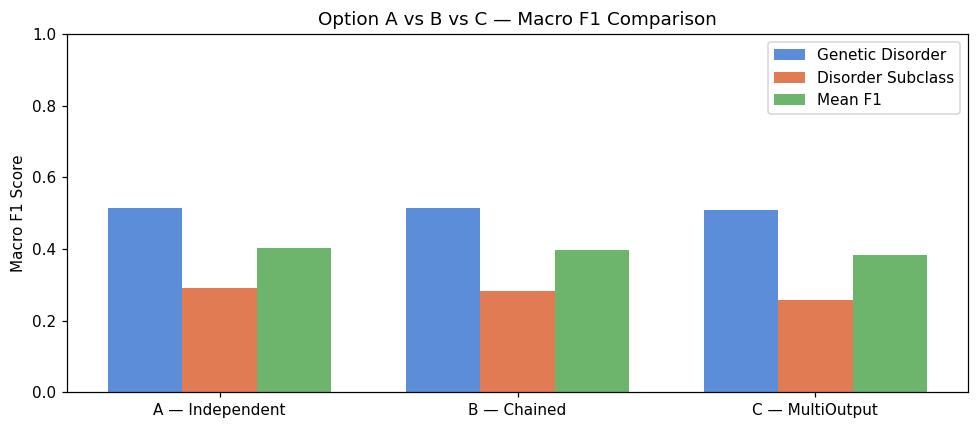

In [25]:
results = pd.DataFrame({
    'Option': ['A — Independent', 'B — Chained', 'C — MultiOutput'],
    'Genetic Disorder F1': [f1_A1, f1_B1, f1_C1],
    'Disorder Subclass F1': [f1_A2, f1_B2, f1_C2],
})
results['Mean F1'] = results[['Genetic Disorder F1', 'Disorder Subclass F1']].mean(axis=1)
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(3)
w = 0.25
ax.bar(x - w,   results['Genetic Disorder F1'],  w, label='Genetic Disorder',  color='#5b8dd9')
ax.bar(x,        results['Disorder Subclass F1'], w, label='Disorder Subclass', color='#e07b54')
ax.bar(x + w,   results['Mean F1'],               w, label='Mean F1',           color='#6db56d')
ax.set_xticks(x)
ax.set_xticklabels(results['Option'])
ax.set_ylabel('Macro F1 Score')
ax.set_title('Option A vs B vs C — Macro F1 Comparison')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

=== Genetic Disorder — Classification Report ===
                                              precision    recall  f1-score   support

 Mitochondrial genetic inheritance disorders       0.64      0.67      0.66      1849
Multifactorial genetic inheritance disorders       0.37      0.50      0.43       375
            Single-gene inheritance diseases       0.50      0.42      0.46      1386

                                    accuracy                           0.56      3610
                                   macro avg       0.50      0.53      0.51      3610
                                weighted avg       0.56      0.56      0.56      3610

=== Disorder Subclass — Classification Report ===
                                     precision    recall  f1-score   support

                        Alzheimer's       0.25      0.04      0.07        23
                             Cancer       0.25      0.07      0.11        15
                    Cystic fibrosis       0.42      0.44      0.

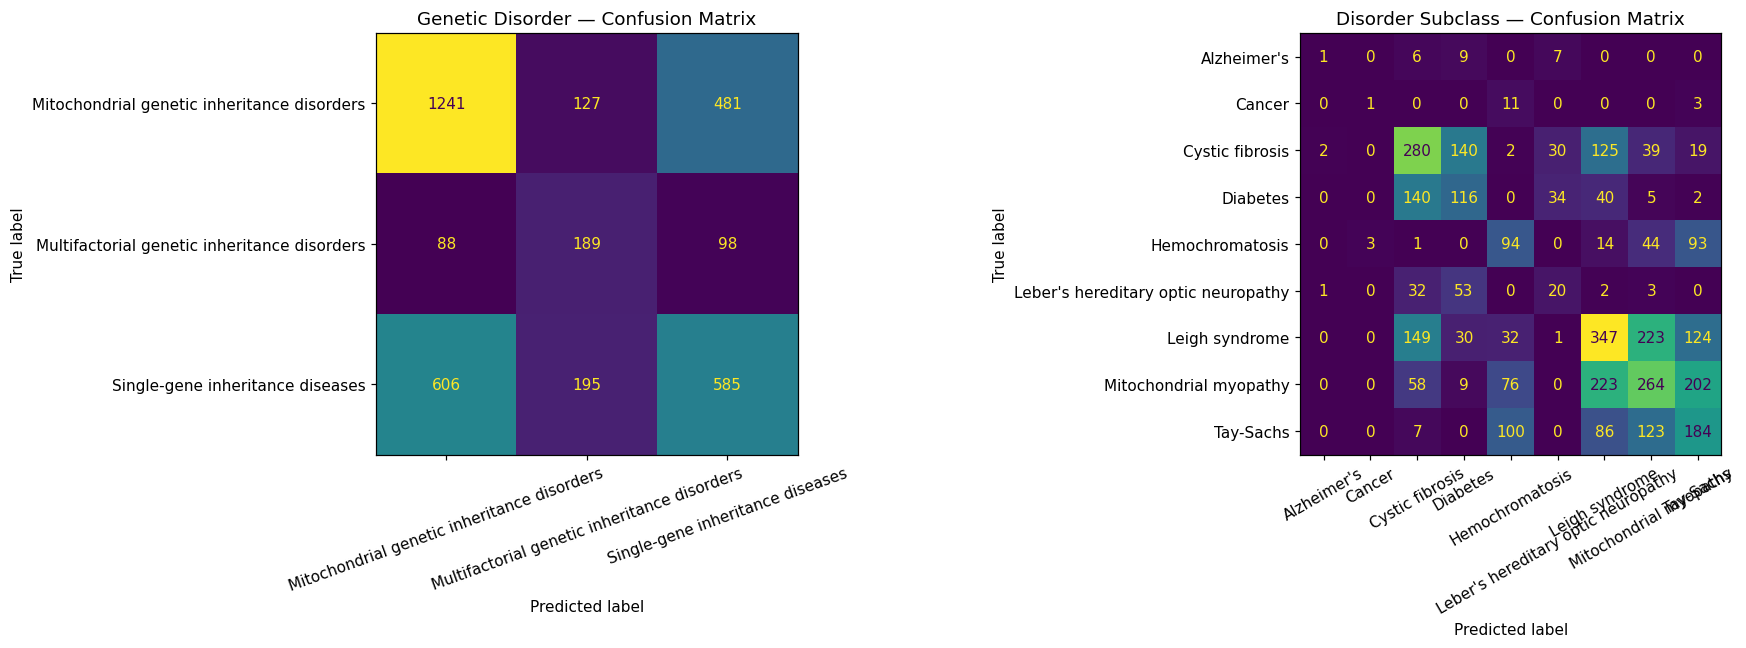

In [26]:
best_pred1 = pred_B1   # swap to pred_A1 or pred_C1
best_pred2 = pred_B2   # swap to pred_A2 or pred_C2

print("=== Genetic Disorder — Classification Report ===")
print(classification_report(y1_val, best_pred1, target_names=le1.classes_))

print("=== Disorder Subclass — Classification Report ===")
print(classification_report(y2_val, best_pred2, target_names=le2.classes_))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ConfusionMatrixDisplay(
    confusion_matrix(y1_val, best_pred1),
    display_labels=le1.classes_
).plot(ax=axes[0], colorbar=False, xticks_rotation=20)
axes[0].set_title('Genetic Disorder — Confusion Matrix')

ConfusionMatrixDisplay(
    confusion_matrix(y2_val, best_pred2),
    display_labels=le2.classes_
).plot(ax=axes[1], colorbar=False, xticks_rotation=30)
axes[1].set_title('Disorder Subclass — Confusion Matrix')

plt.tight_layout()
plt.show()

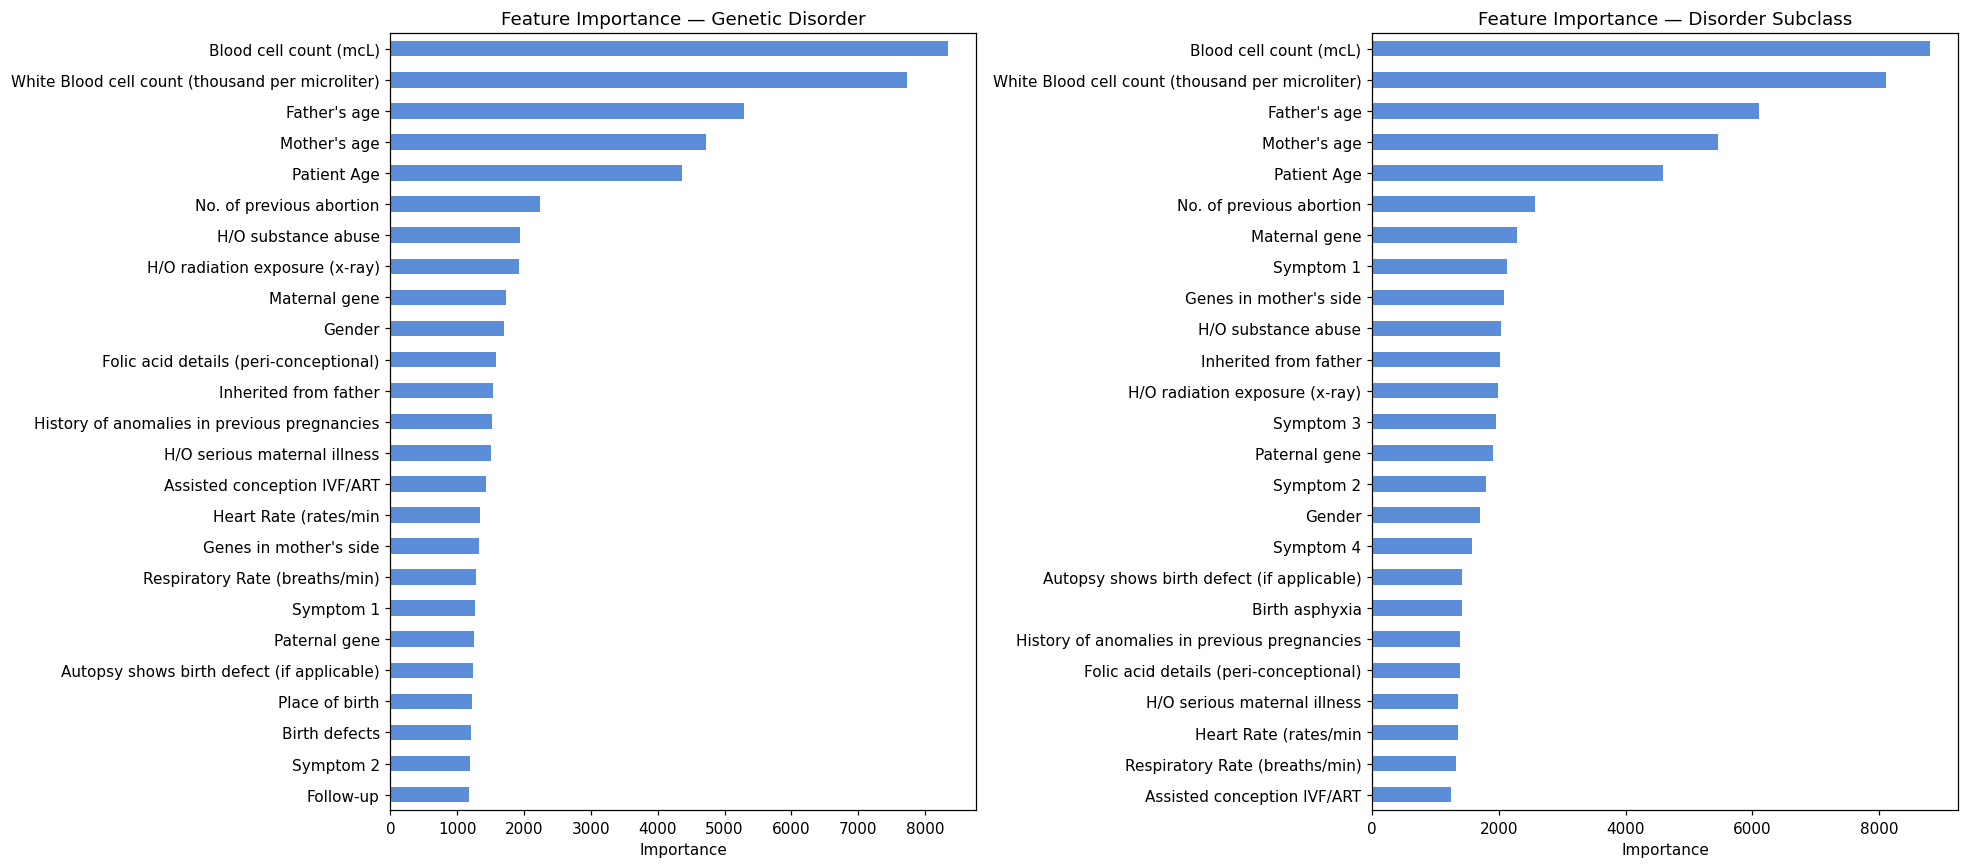

In [27]:
feat_names = X_tr.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, model, title in [
    (axes[0], model_A1, 'Feature Importance — Genetic Disorder'),
    (axes[1], model_A2, 'Feature Importance — Disorder Subclass'),
]:
    imp = pd.Series(model.feature_importances_, index=feat_names)
    imp.nlargest(25).sort_values().plot(kind='barh', ax=ax, color='#5b8dd9')
    ax.set_title(title)
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [28]:
submission = pd.DataFrame({
    'Patient Id': test_df.index if 'Patient Id' not in test_df.columns
                  else pd.read_csv("/kaggle/input/datasets/shreyash28/pharma-dataset/test.csv")['Patient Id'],
    TARGET1: final_pred1,
    TARGET2: final_pred2,
})

submission.to_csv("submission.csv", index=False)
print(f"Saved: {submission.shape}")
display(submission.head())

NameError: name 'final_pred1' is not defined

In [29]:
def add_features(df):
    df = df.copy()

    sym_cols = [c for c in df.columns if 'Symptom' in c]
    if sym_cols:
        df['symptom_sum']  = df[sym_cols].sum(axis=1)
        df['symptom_mean'] = df[sym_cols].mean(axis=1)
        df['symptom_max']  = df[sym_cols].max(axis=1)
        df['symptom_any']  = (df[sym_cols].sum(axis=1) > 0).astype(int)

    if "Mother's age" in df.columns and "Father's age" in df.columns:
        df['parent_age_mean'] = (df["Mother's age"] + df["Father's age"]) / 2
        df['parent_age_diff'] = (df["Mother's age"] - df["Father's age"]).abs()

    if 'Blood cell count (mcl)' in df.columns and \
       'White Blood cell count (thousand per microliter)' in df.columns:
        df['blood_ratio'] = (
            df['Blood cell count (mcl)'] /
            (df['White Blood cell count (thousand per microliter)'] + 1e-5)
        )

    test_cols = [c for c in df.columns if c.startswith('Test')]
    if test_cols:
        df['test_sum']  = df[test_cols].sum(axis=1)
        df['test_mean'] = df[test_cols].mean(axis=1)

    return df

X_fe       = add_features(X)
X_test_fe  = add_features(X_test)

print("After feature engineering:", X_fe.shape)

X_tr_fe, X_val_fe, y1_tr_fe, y1_val_fe, y2_tr_fe, y2_val_fe = train_test_split(
    X_fe, y1_enc, y2_enc,
    test_size=0.2, random_state=42,
    stratify=y1_enc
)
print(f"Train {X_tr_fe.shape} | Val {X_val_fe.shape}")

After feature engineering: (18047, 48)
Train (14437, 48) | Val (3610, 48)


In [30]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights_tr = compute_sample_weight(class_weight='balanced', y=y2_tr_fe)

print("Class weights for Disorder Subclass:")
for cls_idx, cls_name in enumerate(le2.classes_):
    mask = y2_tr_fe == cls_idx
    w    = sample_weights_tr[mask].mean() if mask.sum() > 0 else 0
    print(f"  {cls_name:<40} n={mask.sum():<5} avg_weight={w:.3f}")

Class weights for Disorder Subclass:
  Alzheimer's                              n=110   avg_weight=14.583
  Cancer                                   n=76    avg_weight=21.107
  Cystic fibrosis                          n=2508  avg_weight=0.640
  Diabetes                                 n=1316  avg_weight=1.219
  Hemochromatosis                          n=979   avg_weight=1.639
  Leber's hereditary optic neuropathy      n=476   avg_weight=3.370
  Leigh syndrome                           n=3777  avg_weight=0.425
  Mitochondrial myopathy                   n=3139  avg_weight=0.511
  Tay-Sachs                                n=2056  avg_weight=0.780


In [35]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:", Counter(y2_tr_fe))

min_count = min(Counter(y2_tr_fe).values())
k = min(5, min_count - 1)

smote = SMOTE(k_neighbors=k, random_state=42)
X_tr_sm, y2_tr_sm = smote.fit_resample(X_tr_fe, y2_tr_fe)

_, y1_tr_sm = smote.fit_resample(X_tr_fe, y1_tr_fe)

print("After  SMOTE:", Counter(y2_tr_sm))
print("New train size:", X_tr_sm.shape)

Before SMOTE: Counter({np.int64(6): 3777, np.int64(7): 3139, np.int64(2): 2508, np.int64(8): 2056, np.int64(3): 1316, np.int64(4): 979, np.int64(5): 476, np.int64(0): 110, np.int64(1): 76})
After  SMOTE: Counter({np.int64(7): 3777, np.int64(2): 3777, np.int64(3): 3777, np.int64(8): 3777, np.int64(6): 3777, np.int64(5): 3777, np.int64(4): 3777, np.int64(0): 3777, np.int64(1): 3777})
New train size: (33993, 48)


In [ ]:
lgbm_v2_params = dict(
    n_estimators      = 1000,
    learning_rate     = 0.03,
    num_leaves        = 127,
    max_depth         = -1,
    min_child_samples = 5,
    colsample_bytree  = 0.7,
    subsample         = 0.7,
    subsample_freq    = 1,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

model_v2_t1 = lgb.LGBMClassifier(**lgbm_v2_params)
model_v2_t1.fit(
    X_tr_fe, y1_tr_fe,
    eval_set=[(X_val_fe, y1_val_fe)],
    callbacks=[lgb.early_stopping(80, verbose=False),
               lgb.log_evaluation(period=200)]
)

model_v2_t2 = lgb.LGBMClassifier(**lgbm_v2_params)
model_v2_t2.fit(
    X_tr_sm, y2_tr_sm,
    eval_set=[(X_val_fe, y2_val_fe)],
    callbacks=[lgb.early_stopping(80, verbose=False),
               lgb.log_evaluation(period=200)]
)

pred_v2_t1 = model_v2_t1.predict(X_val_fe)
pred_v2_t2 = model_v2_t2.predict(X_val_fe)

f1_v2_t1 = f1_score(y1_val_fe, pred_v2_t1, average='macro')
f1_v2_t2 = f1_score(y2_val_fe, pred_v2_t2, average='macro')

print(f"\n[v2 — FE + SMOTE] Genetic Disorder  Macro F1 : {f1_v2_t1:.4f}  (was 0.5138)")
print(f"[v2 — FE + SMOTE] Disorder Subclass Macro F1 : {f1_v2_t2:.4f}  (was 0.2913)")

[200]	valid_0's multi_logloss: 0.825626
[400]	valid_0's multi_logloss: 0.823677


In [ ]:
from xgboost import XGBClassifier

xgb_params = dict(
    n_estimators      = 800,
    learning_rate     = 0.03,
    max_depth         = 6,
    min_child_weight  = 1,
    subsample         = 0.8,
    colsample_bytree  = 0.7,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    use_label_encoder = False,
    eval_metric       = 'mlogloss',
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)

xgb_t2 = XGBClassifier(**xgb_params, early_stopping_rounds=50)
xgb_t2.fit(
    X_tr_sm, y2_tr_sm,
    eval_set=[(X_val_fe, y2_val_fe)],
    verbose=False
)

pred_xgb_t2 = xgb_t2.predict(X_val_fe)
f1_xgb_t2   = f1_score(y2_val_fe, pred_xgb_t2, average='macro')
print(f"\n[XGBoost + SMOTE] Disorder Subclass Macro F1 : {f1_xgb_t2:.4f}")

best_t2_model = model_v2_t2 if f1_v2_t2 >= f1_xgb_t2 else xgb_t2
print(f"Using: {'LightGBM v2' if f1_v2_t2 >= f1_xgb_t2 else 'XGBoost'} for Subclass")

In [ ]:
results_all = pd.DataFrame({
    'Model': [
        'A — LightGBM baseline',
        'B — Chained baseline',
        'C — MultiOutput baseline',
        'v2 — FE + SMOTE + Tuned LGBM',
        'v2 — FE + SMOTE + XGBoost',
    ],
    'Genetic Disorder F1': [f1_A1,  f1_B1,  f1_C1,  f1_v2_t1, f1_v2_t1],
    'Disorder Subclass F1': [f1_A2, f1_B2,  f1_C2,  f1_v2_t2, f1_xgb_t2],
})
results_all['Mean F1'] = results_all[['Genetic Disorder F1','Disorder Subclass F1']].mean(axis=1)
results_all = results_all.sort_values('Mean F1', ascending=False).reset_index(drop=True)

print(results_all.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_all))
w = 0.25
ax.bar(x - w,  results_all['Genetic Disorder F1'],  w, label='Genetic Disorder',  color='#5b8dd9')
ax.bar(x,       results_all['Disorder Subclass F1'], w, label='Disorder Subclass', color='#e07b54')
ax.bar(x + w,  results_all['Mean F1'],               w, label='Mean F1',           color='#6db56d')
ax.set_xticks(x)
ax.set_xticklabels(results_all['Model'], rotation=15, ha='right')
ax.set_ylabel('Macro F1 Score')
ax.set_ylim(0, 1)
ax.set_title('All Models — Macro F1 Comparison')
ax.legend()
ax.axhline(0.51, color='#5b8dd9', linestyle='--', alpha=0.4, linewidth=0.8)
ax.axhline(0.29, color='#e07b54', linestyle='--', alpha=0.4, linewidth=0.8)
plt.tight_layout()
plt.show()

In [ ]:
X_test_fe_chain = X_test_fe.copy()
X_test_fe_chain['pred_disorder'] = model_v2_t1.predict(X_test_fe)  # optional for chained

test_raw = pd.read_csv("/kaggle/input/datasets/shreyash28/pharma-dataset/test.csv")

final_pred1 = le1.inverse_transform(model_v2_t1.predict(X_test_fe))
final_pred2 = le2.inverse_transform(best_t2_model.predict(X_test_fe))

submission = pd.DataFrame({
    'Patient Id': test_raw['Patient Id'],
    TARGET1     : final_pred1,
    TARGET2     : final_pred2,
})

submission.to_csv("submission.csv", index=False)
print(f"Saved submission.csv — shape: {submission.shape}")
display(submission.head(10))

print("\nPredicted class distribution:")
print(submission[TARGET1].value_counts())
print(submission[TARGET2].value_counts())

# NEW MODELS

In [ ]:


from catboost import CatBoostClassifier, Pool
from sklearn.metrics import f1_score, classification_report
import numpy as np
import pandas as pd


catboost_params = dict(
    iterations          = 1000,
    learning_rate       = 0.03,
    depth               = 6,
    l2_leaf_reg         = 3.0,
    random_strength     = 1.0,
    bagging_temperature = 1.0,
    od_type             = 'Iter',                       
    od_wait             = 80,                           
    auto_class_weights  = 'Balanced',
    eval_metric         = 'TotalF1:average=Macro',
    random_seed         = 42,
    verbose             = 200,
    task_type           = 'GPU',                       
)

train_pool_t1 = Pool(X_tr_fe,  label=y1_tr_fe)
val_pool_t1   = Pool(X_val_fe, label=y1_val_fe)

train_pool_t2 = Pool(X_tr_sm,  label=y2_tr_sm)       
val_pool_t2   = Pool(X_val_fe, label=y2_val_fe)

print("Training CatBoost — Genetic Disorder...")
cb_t1 = CatBoostClassifier(**catboost_params)
cb_t1.fit(train_pool_t1, eval_set=val_pool_t1, use_best_model=True)

pred_cb_t1 = cb_t1.predict(X_val_fe).flatten()
f1_cb_t1   = f1_score(y1_val_fe, pred_cb_t1, average='macro')
print(f"[CatBoost] Genetic Disorder   Macro F1 : {f1_cb_t1:.4f}  (LGBM was {f1_v2_t1:.4f})")

print("\nTraining CatBoost — Disorder Subclass...")
cb_t2 = CatBoostClassifier(**catboost_params)
cb_t2.fit(train_pool_t2, eval_set=val_pool_t2, use_best_model=True)

pred_cb_t2 = cb_t2.predict(X_val_fe).flatten()
f1_cb_t2   = f1_score(y2_val_fe, pred_cb_t2, average='macro')
print(f"[CatBoost] Disorder Subclass  Macro F1 : {f1_cb_t2:.4f}  (LGBM was {f1_v2_t2:.4f})")


lgbm_proba_t1 = model_v2_t1.predict_proba(X_val_fe)  
lgbm_proba_t2 = model_v2_t2.predict_proba(X_val_fe)  

cb_proba_t1   = cb_t1.predict_proba(X_val_fe)        
cb_proba_t2   = cb_t2.predict_proba(X_val_fe)          


w_lgbm = 0.5
w_cb   = 0.5

ensemble_proba_t1 = w_lgbm * lgbm_proba_t1 + w_cb * cb_proba_t1
ensemble_proba_t2 = w_lgbm * lgbm_proba_t2 + w_cb * cb_proba_t2

pred_ens_t1 = np.argmax(ensemble_proba_t1, axis=1)
pred_ens_t2 = np.argmax(ensemble_proba_t2, axis=1)

f1_ens_t1 = f1_score(y1_val_fe, pred_ens_t1, average='macro')
f1_ens_t2 = f1_score(y2_val_fe, pred_ens_t2, average='macro')

print(f"\n[Ensemble] Genetic Disorder   Macro F1 : {f1_ens_t1:.4f}")
print(f"[Ensemble] Disorder Subclass  Macro F1 : {f1_ens_t2:.4f}")
print(f"[Ensemble] Mean F1            : {(f1_ens_t1 + f1_ens_t2) / 2:.4f}")




best_w_t1, best_f1_t1 = 0.5, 0.0
best_w_t2, best_f1_t2 = 0.5, 0.0

for w in np.arange(0.0, 1.05, 0.05):
    proba = w * lgbm_proba_t1 + (1 - w) * cb_proba_t1
    f1    = f1_score(y1_val_fe, np.argmax(proba, axis=1), average='macro')
    if f1 > best_f1_t1:
        best_f1_t1, best_w_t1 = f1, w

    proba = w * lgbm_proba_t2 + (1 - w) * cb_proba_t2
    f1    = f1_score(y2_val_fe, np.argmax(proba, axis=1), average='macro')
    if f1 > best_f1_t2:
        best_f1_t2, best_w_t2 = f1, w

print(f"Best T1 weights — LGBM: {best_w_t1:.2f} | CatBoost: {1-best_w_t1:.2f} → F1: {best_f1_t1:.4f}")
print(f"Best T2 weights — LGBM: {best_w_t2:.2f} | CatBoost: {1-best_w_t2:.2f} → F1: {best_f1_t2:.4f}")

final_proba_t1 = best_w_t1 * lgbm_proba_t1 + (1 - best_w_t1) * cb_proba_t1
final_proba_t2 = best_w_t2 * lgbm_proba_t2 + (1 - best_w_t2) * cb_proba_t2

pred_final_t1  = np.argmax(final_proba_t1, axis=1)
pred_final_t2  = np.argmax(final_proba_t2, axis=1)

print(f"\n[Tuned Ensemble] Mean F1 : {(best_f1_t1 + best_f1_t2) / 2:.4f}")


results = pd.DataFrame({
    'Model': [
        'LightGBM v2',
        'CatBoost',
        'Ensemble (equal weights)',
        'Ensemble (tuned weights)',
    ],
    'Genetic Disorder F1': [f1_v2_t1, f1_cb_t1, f1_ens_t1, best_f1_t1],
    'Disorder Subclass F1': [f1_v2_t2, f1_cb_t2, f1_ens_t2, best_f1_t2],
})
results['Mean F1'] = results[['Genetic Disorder F1', 'Disorder Subclass F1']].mean(axis=1)
results = results.sort_values('Mean F1', ascending=False).reset_index(drop=True)

print("\n" + results.to_string(index=False))


test_lgbm_proba_t1 = model_v2_t1.predict_proba(X_test_fe)
test_lgbm_proba_t2 = model_v2_t2.predict_proba(X_test_fe)

test_cb_proba_t1   = cb_t1.predict_proba(X_test_fe)
test_cb_proba_t2   = cb_t2.predict_proba(X_test_fe)

test_final_proba_t1 = best_w_t1 * test_lgbm_proba_t1 + (1 - best_w_t1) * test_cb_proba_t1
test_final_proba_t2 = best_w_t2 * test_lgbm_proba_t2 + (1 - best_w_t2) * test_cb_proba_t2

final_pred1 = le1.inverse_transform(np.argmax(test_final_proba_t1, axis=1))
final_pred2 = le2.inverse_transform(np.argmax(test_final_proba_t2, axis=1))

test_raw   = pd.read_csv("/kaggle/input/datasets/shreyash28/pharma-dataset/test.csv")
submission = pd.DataFrame({
    'Patient Id':        test_raw['Patient Id'],
    'Genetic Disorder':  final_pred1,
    'Disorder Subclass': final_pred2,
})

submission.to_csv("submission.csv", index=False)
print(f"Saved submission.csv — shape: {submission.shape}")
print(submission.head(10))

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.base import clone

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool


def add_features(df):
    df = df.copy()

    sym_cols = [c for c in df.columns if "Symptom" in c]
    if sym_cols:
        df["symptom_sum"]  = df[sym_cols].sum(axis=1)
        df["symptom_mean"] = df[sym_cols].mean(axis=1)
        df["symptom_max"]  = df[sym_cols].max(axis=1)
        df["symptom_any"]  = (df[sym_cols].sum(axis=1) > 0).astype(int)

    if "Mother's age" in df.columns and "Father's age" in df.columns:
        df["parent_age_mean"] = (df["Mother's age"] + df["Father's age"]) / 2
        df["parent_age_diff"] = (df["Mother's age"] - df["Father's age"]).abs()

    if "Blood cell count (mcl)" in df.columns and "White Blood cell count (thousand per microliter)" in df.columns:
        df["blood_ratio"] = df["Blood cell count (mcl)"] / (df["White Blood cell count (thousand per microliter)"] + 1e-5)

    test_cols = [c for c in df.columns if c.startswith("Test")]
    if test_cols:
        df["test_sum"] = df[test_cols].sum(axis=1)
        df["test_mean"] = df[test_cols].mean(axis=1)

    return df


def make_base_models():
    cb = CatBoostClassifier(
        iterations=1200,
        learning_rate=0.03,
        depth=6,
        loss_function="MultiClass",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=0
    )

    lgbm = LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=127,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    xgb = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    meta = LogisticRegression(max_iter=2000, class_weight="balanced")
    return cb, lgbm, xgb, meta


def oof_stack_train(X, y, models, n_classes, use_catboost=False):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    oof_preds = [np.zeros((len(X), n_classes)) for _ in models]
    trained_models = [[] for _ in models]

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        for m_idx, model in enumerate(models):
            m = clone(model)

            if use_catboost and isinstance(m, CatBoostClassifier):
                m.fit(X_tr, y_tr, eval_set=(X_va, y_va), use_best_model=True)
                proba = m.predict_proba(X_va)
            else:
                m.fit(X_tr, y_tr)
                proba = m.predict_proba(X_va)

            oof_preds[m_idx][va_idx] = proba
            trained_models[m_idx].append(m)

    stacked_oof = np.hstack(oof_preds)
    return stacked_oof, trained_models


def fit_meta_model(stacked_oof, y):
    meta = LogisticRegression(max_iter=2000, class_weight="balanced")
    meta.fit(stacked_oof, y)
    return meta


def predict_stack(models, meta_model, X):
    probs = []
    for m in models:
        probs.append(m.predict_proba(X))
    stacked = np.hstack(probs)
    return meta_model.predict(stacked), meta_model.predict_proba(stacked)


cb, lgbm, xgb, meta = make_base_models()

base_models_t1 = [cb, lgbm, xgb]
oof_t1, trained_t1 = oof_stack_train(X_tr_fe, y1_tr, base_models_t1, n_classes=len(np.unique(y1_tr)), use_catboost=True)
meta_t1 = fit_meta_model(oof_t1, y1_tr)

final_t1_models = []
for model in base_models_t1:
    m = clone(model)
    if isinstance(m, CatBoostClassifier):
        m.fit(X_tr_fe, y1_tr, verbose=0)
    else:
        m.fit(X_tr_fe, y1_tr)
    final_t1_models.append(m)

val_pred_t1, val_proba_t1 = predict_stack(final_t1_models, meta_t1, X_val_fe)
print("T1 Macro F1:", f1_score(y1_val, val_pred_t1, average="macro"))

t1_proba_train = meta_t1.predict_proba(np.hstack([
    final_t1_models[0].predict_proba(X_tr_fe),
    final_t1_models[1].predict_proba(X_tr_fe),
    final_t1_models[2].predict_proba(X_tr_fe),
]))

t1_proba_val = val_proba_t1

X_tr_t2 = X_tr_fe.copy()
X_val_t2 = X_val_fe.copy()

for i in range(t1_proba_train.shape[1]):
    X_tr_t2[f"t1_proba_{i}"] = t1_proba_train[:, i]
    X_val_t2[f"t1_proba_{i}"] = t1_proba_val[:, i]

base_models_t2 = [cb, lgbm, xgb]
oof_t2, trained_t2 = oof_stack_train(X_tr_t2, y2_tr, base_models_t2, n_classes=len(np.unique(y2_tr)), use_catboost=True)
meta_t2 = fit_meta_model(oof_t2, y2_tr)

final_t2_models = []
for model in base_models_t2:
    m = clone(model)
    if isinstance(m, CatBoostClassifier):
        m.fit(X_tr_t2, y2_tr, verbose=0)
    else:
        m.fit(X_tr_t2, y2_tr)
    final_t2_models.append(m)

val_pred_t2, val_proba_t2 = predict_stack(final_t2_models, meta_t2, X_val_t2)
print("T2 Macro F1:", f1_score(y2_val, val_pred_t2, average="macro"))